In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("data/raw/raw_traffic.csv")

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
rows, columns = df.shape
print(f"Total Rows    : {rows}")
print(f"Total Columns : {columns}")

Total Rows    : 2070115
Total Columns : 43


In [4]:
print("All Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")
    

All Column Names:
1. SeqID
2. Date Of Stop
3. Time Of Stop
4. Agency
5. SubAgency
6. Description
7. Location
8. Latitude
9. Longitude
10. Accident
11. Belts
12. Personal Injury
13. Property Damage
14. Fatal
15. Commercial License
16. HAZMAT
17. Commercial Vehicle
18. Alcohol
19. Work Zone
20. Search Conducted
21. Search Disposition
22. Search Outcome
23. Search Reason
24. Search Reason For Stop
25. Search Type
26. Search Arrest Reason
27. State
28. VehicleType
29. Year
30. Make
31. Model
32. Color
33. Violation Type
34. Charge
35. Article
36. Contributed To Accident
37. Race
38. Gender
39. Driver City
40. Driver State
41. DL State
42. Arrest Type
43. Geolocation


In [5]:
df.head()

,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,52282e8c-f2e1-4bb5-8509-2d5e4f8da8ca,05/01/2023,23:11:00,MCP,"3rd District, Silver Spring",OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,BRIGGS CHANEY RD @ COLUMIBA PIKE,0.000000,0.00000,No,...,13-401(b1),Transportation Article,False,WHITE,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(0.0, 0.0)"
1,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVING TO DRIVE MOTOR VEHICLE ON HIGHWAY WITH...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,16-101(a1),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
2,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO DISPLAY REGISTRATION CARD UPON DEMA...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,13-409(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
3,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVER OF MOTOR VEHICLE FOLLOWING VEHICLE CLOS...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-310(a),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
4,b66f253b-af29-4bc4-bb73-93755ca2a779,08/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO CONTROL VEH. SPEED ON HWY. TO AVOID...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-801(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"


In [6]:
print("Data Types:")
print(df.dtypes)

Data Types:
SeqID                       object
Date Of Stop                object
Time Of Stop                object
Agency                      object
SubAgency                   object
Description                 object
Location                    object
Latitude                   float64
Longitude                  float64
Accident                    object
Belts                       object
Personal Injury             object
Property Damage             object
Fatal                       object
Commercial License          object
HAZMAT                      object
Commercial Vehicle          object
Alcohol                     object
Work Zone                   object
Search Conducted            object
Search Disposition          object
Search Outcome              object
Search Reason               object
Search Reason For Stop      object
Search Type                 object
Search Arrest Reason        object
State                       object
VehicleType                 object
Year    

In [7]:
df.describe()

,Latitude,Longitude,Year
count,2.070115e+06,2.070115e+06,2.059470e+06
mean,3.613803e+01,-7.130162e+01,2.007615e+03
std,1.032062e+01,2.036307e+01,8.489762e+01
min,0.000000e+00,-1.512560e+02,0.000000e+00
25%,3.901642e+01,-7.719294e+01,2.003000e+03
50%,3.906618e+01,-7.708753e+01,2.008000e+03
75%,3.913717e+01,-7.702696e+01,2.013000e+03
max,4.154316e+01,3.906444e+01,9.999000e+03


Identify and remove duplicate and inconsistent records

In [8]:
def check_missing_values(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count' : missing_count,
        'Missing %' : missing_percent.round(2) 
    })

    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending = False)
    return missing_df

In [9]:
missing_df = check_missing_values(df)
missing_df



,Missing Count,Missing %
Search Arrest Reason,2008149,97.01
Search Disposition,1980574,95.67
Search Reason,1980574,95.67
Search Type,1980582,95.67
Search Outcome,805416,38.91
Search Reason For Stop,786428,37.99
Search Conducted,786125,37.97
Article,92680,4.48
Color,22300,1.08
Year,10645,0.51


In [10]:
def check_duplicates(df):
    total_duplicates = df.duplicated().sum()
    seqid_duplicates = df['SeqID'].duplicated().sum()

    print(f"Total Duplicate Rows: {total_duplicates}")
    print(f"Duplicate SeqID Count: {seqid_duplicates}")


In [11]:
check_duplicates(df)


Total Duplicate Rows: 2354
Duplicate SeqID Count: 892035


In [12]:
def check_unique_values(df):
    print("\nGender Values:", df['Gender'].unique())
    print("\nRace Values:", df['Race'].unique())
    print("\nViolation Type Values:", df['Violation Type'].unique())
    print("\nVehicleType Values:", df['VehicleType'].unique())


In [13]:
check_unique_values(df)



Gender Values: ['M' 'F' 'U']

Race Values: ['WHITE' 'HISPANIC' 'BLACK' 'OTHER' 'ASIAN' 'NATIVE AMERICAN']

Violation Type Values: ['Citation' 'Warning' 'ESERO' 'SERO']

VehicleType Values: ['02 - Automobile' '19 - Moped' '05 - Light Duty Truck'
 '07 - Truck/Road Tractor' '01 - Motorcycle' '20 - Commercial Rig'
 '28 - Other' '12 - School Bus' '03 - Station Wagon'
 '25 - Utility Trailer' '06 - Heavy Duty Truck'
 '08 - Recreational Vehicle' '29 - Unknown' '04 - Limousine'
 '10 - Transit Bus' '27 - Farm Equipment' '11 - Cross Country Bus'
 '21 - Tandem Trailer' '16 - Fire(Non-Emerg)' '09 - Farm Vehicle'
 '18 - Police Vehicle' '23 - Travel/Home Trailer' '15 - Fire(Emerg)'
 '14 - Ambulance(Non-Emerg)' '13 - Ambulance(Emerg)' '26 - Boat Trailer'
 '18 - Police(Non-Emerg)' '22 - Mobile Home' '24 - Camper'
 '13 - Ambulance' '15 - Fire Vehicle' '14 - Ambulance'
 '17 - Police(Emerg)' '30 - Unknown' '28 - Electric Bicycle' '29 - Other']


In [14]:
def remove_duplicates(df):
    before = df.shape[0]
    df = df.drop_duplicates()

    after = df.shape[0]

    print(f"Rows before: {before}")
    print(f"Rows after : {after}")
    print(f"Removed    : {before - after}")

    return df

In [15]:
df = remove_duplicates(df)

Rows before: 2070115
Rows after : 2067761
Removed    : 2354


Standardize date-time formats

In [16]:
df['stop_datetime'] = pd.to_datetime(
    df['Date Of Stop'] + ' ' + df['Time Of Stop'],
    format ='%m/%d/%Y %H:%M:%S',
    errors = 'coerce'
)
df['date'] = df['stop_datetime'].dt.strftime('%d/%m/%Y')
df['time'] = df['stop_datetime'].dt.strftime('%I:%M:%S %p')

In [17]:
df['stop_datetime']

0         2023-05-01 23:11:00
1         2023-08-31 16:41:00
2         2023-08-31 16:41:00
3         2023-08-31 16:41:00
4         2023-08-31 16:41:00
                  ...        
2070110   2025-12-04 13:14:00
2070111   2025-12-04 15:14:00
2070112   2025-12-04 21:18:00
2070113   2025-12-04 07:28:00
2070114   2025-12-04 13:33:00
Name: stop_datetime, Length: 2067761, dtype: datetime64[ns]

Normalize categorical variables (race, gender, vehicle data, violation codes)

In [18]:
#Gender
df['Gender'] = df['Gender'].astype(str).str.strip().str.upper()
df['Gender'] = df['Gender'].replace({
    'MALE': 'M',
    'FEMALE': 'F',
    'UNKNOWN': 'U',
    'NAN': 'U'
})

#Race
df['Race'] = df['Race'].astype(str).str.strip().str.upper()

#Vehicle
df['VehicleType'] = df['VehicleType'].astype(str).str.strip().str.upper()
df['VehicleType'] = df['VehicleType'].replace({
    '13 - AMBULANCE' :      '13 - AMBULANCE(EMERG)',
    '14 - AMBULANCE' :      '14 - AMBULANCE(NON-EMERG)',
    '15 - FIRE VEHICLE' :   '15 - FIRE(EMERG)',
    '18 - POLICE VEHICLE' : '18 - POLICE(NON-EMERG)',
    '29 - OTHER' :          '28 - OTHER',
    '30 - UNKNOWN' :        '29 - UNKNOWN'
})

#Violation
df['Violation Type'] = df['Violation Type'].astype(str).str.strip().str.upper()
df['Violation Type'] = df['Violation Type'].replace({
    'SERO' : 'ESERO' 
})


In [19]:
df['Violation Type'].value_counts()

Violation Type
WARNING     1089807
CITATION     885280
ESERO         92674
Name: count, dtype: int64

In [20]:
df['Race'].value_counts()

Race
WHITE              690418
BLACK              655425
HISPANIC           463921
OTHER              137829
ASIAN              116652
NATIVE AMERICAN      3516
Name: count, dtype: int64

In [21]:
df['VehicleType'].value_counts().sort_index()

VehicleType
01 - MOTORCYCLE                19052
02 - AUTOMOBILE              1833630
03 - STATION WAGON             28614
04 - LIMOUSINE                   959
05 - LIGHT DUTY TRUCK         108173
06 - HEAVY DUTY TRUCK          16426
07 - TRUCK/ROAD TRACTOR         1816
08 - RECREATIONAL VEHICLE       5502
09 - FARM VEHICLE                108
10 - TRANSIT BUS                 685
11 - CROSS COUNTRY BUS            66
12 - SCHOOL BUS                  432
13 - AMBULANCE(EMERG)             15
14 - AMBULANCE(NON-EMERG)         22
15 - FIRE(EMERG)                  16
16 - FIRE(NON-EMERG)               5
17 - POLICE(EMERG)                 5
18 - POLICE(NON-EMERG)            26
19 - MOPED                      2308
20 - COMMERCIAL RIG             1144
21 - TANDEM TRAILER               88
22 - MOBILE HOME                  27
23 - TRAVEL/HOME TRAILER          34
24 - CAMPER                       26
25 - UTILITY TRAILER            1965
26 - BOAT TRAILER                101
27 - FARM EQUIPMENT       

Validate and clean geographic coordinates

In [22]:
print(df.columns.tolist())

['SeqID', 'Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency', 'Description', 'Location', 'Latitude', 'Longitude', 'Accident', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone', 'Search Conducted', 'Search Disposition', 'Search Outcome', 'Search Reason', 'Search Reason For Stop', 'Search Type', 'Search Arrest Reason', 'State', 'VehicleType', 'Year', 'Make', 'Model', 'Color', 'Violation Type', 'Charge', 'Article', 'Contributed To Accident', 'Race', 'Gender', 'Driver City', 'Driver State', 'DL State', 'Arrest Type', 'Geolocation', 'stop_datetime', 'date', 'time']


In [23]:
print(df['Latitude'].min())
print(df['Latitude'].max())
print(df['Longitude'].min())
print(df['Longitude'].max())

0.0
41.5431599333333
-151.255986666667
39.064435


In [24]:
df[['Latitude', 'Longitude']].describe()

,Latitude,Longitude
count,2.067761e+06,2.067761e+06
mean,3.614126e+01,-7.130799e+01
std,1.031544e+01,2.035284e+01
min,0.000000e+00,-1.512560e+02
25%,3.901645e+01,-7.719297e+01
50%,3.906620e+01,-7.708758e+01
75%,3.913720e+01,-7.702697e+01
max,4.154316e+01,3.906444e+01


In [25]:
df['Latitude'] = pd.to_numeric(df['Latitude'], errors = 'coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors = 'coerce')

df = df[
    (df['Latitude'].between(-90, 90)) &
    (df['Longitude'].between(-180, 180))
    ]

In [26]:
df[~((df['Latitude'].between(-90, 90)) & (df['Longitude'].between(-180, 180)))]

,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation,stop_datetime,date,time


In [27]:
((df['Latitude'] == 0) | (df['Longitude'] == 0)).sum()

np.int64(155745)

In [28]:
df.loc[
    (df['Latitude'] == 0) | (df['Longitude'] == 0),
    ['Latitude', 'Longitude']
].head()

,Latitude,Longitude
0,0.0,0.0
26,0.0,0.0
27,0.0,0.0
28,0.0,0.0
29,0.0,0.0


In [29]:
df.loc[df['Latitude'] == 0, 'Latitude'] = np.nan
df.loc[df['Longitude'] == 0, 'Longitude'] = np.nan

In [30]:
print("Positive longitude:", (df['Longitude'] > 0).sum())
print("Less than -125:", (df['Longitude'] < -125).sum())

Positive longitude: 2
Less than -125: 2


In [31]:
df[
    (df['Longitude'] > 0) | (df['Longitude'] < -125)
][['Latitude', 'Longitude', 'Location']]

,Latitude,Longitude,Location
903824,0.583333,39.064435,VEIRSMILL RD AT PARKLAND DR
914537,10.040743,-151.255987,US 270 AT 370
936393,10.040743,-151.255987,US 270 AT 370
1677212,NaN,0.016667,8800 BLK WALDEN RD


In [32]:
bad_coord_mask = (
    (df['Longitude'] > 0) |
    (df['Longitude'] < -125)
)

df.loc[bad_coord_mask, ['Latitude', 'Longitude']] = np.nan

Handle missing, invalid, or out-of-range values

In [33]:
df.describe(include='all')

,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation,stop_datetime,date,time
count,2067761,2067761,2067761,2067761,2067761,2067751,2067757,1.912013e+06,1.912013e+06,2067761,...,2067761,2067761,2067247,2067750,2066832,2067761,2067761,2067761,2067761,2067761
unique,1178080,5086,1440,1,9,17806,269352,NaN,NaN,2,...,6,3,9374,68,72,19,1026161,NaN,5086,1440
top,33c49de3-9e36-4f36-9326-b59a95e86fe8,03/17/2015,23:30:00,MCP,"4th District, Wheaton",DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC...,MONTGOMERY VILLAGE AVE @ RUSSELL AVE,NaN,NaN,No,...,WHITE,M,SILVER SPRING,MD,MD,A - Marked Patrol,"(0.0, 0.0)",NaN,17/03/2015,11:30:00 PM
freq,59,1278,2992,2067761,448580,171274,2449,NaN,NaN,2011283,...,690418,1392231,502406,1869718,1803488,1655405,155744,NaN,1278,2992
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.908523e+01,-7.711643e+01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-09 09:44:15.577776896,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.574457e-03,-1.203847e+02,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-01-01 00:43:00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.903303e+01,-7.720103e+01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-10-12 14:27:00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.907487e+01,-7.709804e+01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-01-27 18:58:00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.914478e+01,-7.704663e+01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-22 10:21:00,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.154316e+01,-1.373291e-03,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-05 22:32:00,NaN,NaN


In [34]:
check_missing_values(df)

,Missing Count,Missing %
Search Arrest Reason,2006050,97.02
Search Disposition,1978521,95.68
Search Reason,1978521,95.68
Search Type,1978528,95.68
Search Outcome,804561,38.91
Search Reason For Stop,785598,37.99
Search Conducted,785295,37.98
Latitude,155748,7.53
Longitude,155748,7.53
Article,92674,4.48


In [35]:
print(df['Search Outcome'].value_counts(dropna=False))
print("---")
print(df['Search Reason For Stop'].value_counts(dropna=False))
print("---")
print(df['Search Conducted'].value_counts(dropna=False))

Search Outcome
NaN                   804561
Warning               638394
Citation              525567
Arrest                 62574
SERO                   36662
Recovered Evidence         3
Name: count, dtype: int64
---
Search Reason For Stop
NaN              785598
21-201(a1)       154258
21-801.1          98194
13-411(f)         68610
21-707(a)         60210
                  ...  
16-301(c)             1
21-205(c)             1
13-501(a)             1
21-504(b)             1
11-393.10(4f)         1
Name: count, Length: 843, dtype: int64
---
Search Conducted
No     1193226
NaN     785295
Yes      89240
Name: count, dtype: int64


In [36]:
df['Search Outcome'].value_counts()

Search Outcome
Warning               638394
Citation              525567
Arrest                 62574
SERO                   36662
Recovered Evidence         3
Name: count, dtype: int64

In [37]:
cols_to_drop = [
    'Search Arrest Reason',
    'Search Disposition',
    'Search Reason',
    'Search Type',
    'Search Reason For Stop'
]

df = df.drop(columns = cols_to_drop)

In [38]:
#Search Outcome
df['Search Outcome'] = df['Search Outcome'].fillna('UNKNOWN')
df['Search Outcome'] = df['Search Outcome'].replace({'SERO': 'ESERO'})

#Search Conducted
df['Search Conducted'] = df['Search Conducted'].fillna('UNKNOWN')

In [39]:
df['Search Conducted'].value_counts(dropna=False)

Search Conducted
No         1193226
UNKNOWN     785295
Yes          89240
Name: count, dtype: int64

In [40]:
cols_cat = ['Article', 'Color', 'DL State', 'Driver City', 'Model']

for col in cols_cat:
    df[col] = df[col].fillna('UNKNOWN')


In [41]:
invalid_years = df[(df['Year'] < 1900) | (df['Year'] > 2025)]
invalid_years.shape

(2781, 41)

In [42]:
df.loc[
    (df['Year'] < 1900) | (df['Year'] > 2025),
    'Year'
].value_counts().sort_index()

Year
2026.0    203
2027.0      3
2028.0      2
2031.0      6
2033.0      6
         ... 
9624.0      1
9705.0      1
9867.0      1
9890.0      2
9999.0     62
Name: count, Length: 253, dtype: int64

In [43]:
invalid_mask = (df['Year'] < 1900) | (df['Year'] > 2025)
df.loc[invalid_mask, 'Year'] = np.nan

df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year']

0          2007.0
1          2005.0
2          2005.0
3          2005.0
4          2005.0
            ...  
2070110    2011.0
2070111    2020.0
2070112    2010.0
2070113    2019.0
2070114    2019.0
Name: Year, Length: 2067761, dtype: float64

In [44]:
((df['Year'] < 1900) | (df['Year'] > 2025)).sum()

np.int64(0)

In [45]:
df.isnull().sum()

SeqID                           0
Date Of Stop                    0
Time Of Stop                    0
Agency                          0
SubAgency                       0
Description                    10
Location                        4
Latitude                   155748
Longitude                  155748
Accident                        0
Belts                           0
Personal Injury                 0
Property Damage                 0
Fatal                           0
Commercial License              0
HAZMAT                          0
Commercial Vehicle              0
Alcohol                         0
Work Zone                       0
Search Conducted                0
Search Outcome                  0
State                          59
VehicleType                     0
Year                            0
Make                           74
Model                           0
Color                           0
Violation Type                  0
Charge                          0
Article       

In [46]:
cols_remaining = ['Description', 'Location', 'State', 'Make', 'Driver State']

for col in cols_remaining:
    df[col] = df[col].fillna('UNKNOWN')

In [47]:
df.isnull().sum().sum()

np.int64(311496)

In [48]:
for col in df.columns:
    print(col, df[col].nunique())

SeqID 1178080
Date Of Stop 5086
Time Of Stop 1440
Agency 1
SubAgency 9
Description 17807
Location 269353
Latitude 391514
Longitude 436118
Accident 2
Belts 2
Personal Injury 2
Property Damage 2
Fatal 2
Commercial License 2
HAZMAT 2
Commercial Vehicle 2
Alcohol 2
Work Zone 2
Search Conducted 3
Search Outcome 6
State 73
VehicleType 30
Year 86
Make 4935
Model 23386
Color 27
Violation Type 3
Charge 1199
Article 7
Contributed To Accident 2
Race 6
Gender 3
Driver City 9374
Driver State 69
DL State 73
Arrest Type 19
Geolocation 1026161
stop_datetime 1021271
date 5086
time 1440


In [49]:
bool_cols = [
    'Accident', 'Belts', 'Personal Injury', 'Property Damage',
    'Fatal', 'Commercial License', 'HAZMAT', 'Commercial Vehicle',
    'Alcohol', 'Work Zone', 'Search Conducted',
    'Contributed To Accident'
]

for col in bool_cols:
    print(f"\n")
    print(df[col].value_counts(dropna=False).head(10))



Accident
No     2011283
Yes      56478
Name: count, dtype: int64


Belts
No     2003455
Yes      64306
Name: count, dtype: int64


Personal Injury
No     2042652
Yes      25109
Name: count, dtype: int64


Property Damage
No     2022620
Yes      45141
Name: count, dtype: int64


Fatal
No     2067194
Yes        567
Name: count, dtype: int64


Commercial License
No     2009984
Yes      57777
Name: count, dtype: int64


HAZMAT
No     2067608
Yes        153
Name: count, dtype: int64


Commercial Vehicle
No     2061155
Yes       6606
Name: count, dtype: int64


Alcohol
No     2065146
Yes       2615
Name: count, dtype: int64


Work Zone
No     2067313
Yes        448
Name: count, dtype: int64


Search Conducted
No         1193226
UNKNOWN     785295
Yes          89240
Name: count, dtype: int64


Contributed To Accident
False    2011283
True       56478
Name: count, dtype: int64


In [50]:
bool_cols_yes_no = [
    'Accident', 'Belts', 'Personal Injury', 'Property Damage',
    'Fatal', 'Commercial License', 'HAZMAT',
    'Commercial Vehicle', 'Alcohol', 'Work Zone'
]

for col in bool_cols_yes_no:
    df[col] = df[col].map({'Yes' : True, 'No' : False})

df['Contributed To Accident'] = df['Contributed To Accident'].astype(bool)

In [51]:
print((df == 'Yes').sum())

SeqID                          0
Date Of Stop                   0
Time Of Stop                   0
Agency                         0
SubAgency                      0
Description                    0
Location                       0
Latitude                       0
Longitude                      0
Accident                       0
Belts                          0
Personal Injury                0
Property Damage                0
Fatal                          0
Commercial License             0
HAZMAT                         0
Commercial Vehicle             0
Alcohol                        0
Work Zone                      0
Search Conducted           89240
Search Outcome                 0
State                          0
VehicleType                    0
Year                           0
Make                           0
Model                          0
Color                          0
Violation Type                 0
Charge                         0
Article                        0
Contribute

In [52]:
df[
    ['Accident', 'Search Conducted', 'Contributed To Accident']
].dtypes

Accident                     bool
Search Conducted           object
Contributed To Accident      bool
dtype: object

In [53]:
df['Search Conducted'] = df['Search Conducted'].astype('category')

In [54]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 2067761 entries, 0 to 2070114
Data columns (total 41 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   SeqID                    object        
 1   Date Of Stop             object        
 2   Time Of Stop             object        
 3   Agency                   object        
 4   SubAgency                object        
 5   Description              object        
 6   Location                 object        
 7   Latitude                 float64       
 8   Longitude                float64       
 9   Accident                 bool          
 10  Belts                    bool          
 11  Personal Injury          bool          
 12  Property Damage          bool          
 13  Fatal                    bool          
 14  Commercial License       bool          
 15  HAZMAT                   bool          
 16  Commercial Vehicle       bool          
 17  Alcohol                  bool   

In [55]:
for col in df.columns:
    if df[col].nunique() < 5000:
        print(f"\n{col}")
        print(df[col].unique())


Time Of Stop
['23:11:00' '16:41:00' '23:55:00' ... '04:49:00' '03:52:00' '05:22:00']

Agency
['MCP']

SubAgency
['3rd District, Silver Spring'
 '6th District, Gaithersburg / Montgomery Village' '4th District, Wheaton'
 '5th District, Germantown' '2nd District, Bethesda'
 '1st District, Rockville' 'Headquarters and Special Operations' 'W15'
 'S15']

Accident
[False  True]

Belts
[False  True]

Personal Injury
[False  True]

Property Damage
[False  True]

Fatal
[False  True]

Commercial License
[False  True]

HAZMAT
[False  True]

Commercial Vehicle
[False  True]

Alcohol
[False  True]

Work Zone
[False  True]

Search Conducted
['No', 'UNKNOWN', 'Yes']
Categories (3, object): ['No', 'UNKNOWN', 'Yes']

Search Outcome
['Citation' 'UNKNOWN' 'Arrest' 'Warning' 'ESERO' 'Recovered Evidence']

State
['MD' 'XX' 'VA' 'NY' 'DC' 'WI' 'NC' 'GA' 'MN' 'OH' 'PA' 'IL' 'KY' 'TX'
 'NM' 'FL' 'DE' 'AR' 'WY' 'NJ' 'WV' 'OR' 'TN' 'CA' 'IA' 'UT' 'IN' 'AZ'
 'MO' 'MA' 'LA' 'MS' 'ND' 'SC' 'ME' 'US' 'NV' 'MI' 'PE'

In [56]:
for col in df.columns:
    print(col, '-->', df[col].nunique())

SeqID --> 1178080
Date Of Stop --> 5086
Time Of Stop --> 1440
Agency --> 1
SubAgency --> 9
Description --> 17807
Location --> 269353
Latitude --> 391514
Longitude --> 436118
Accident --> 2
Belts --> 2
Personal Injury --> 2
Property Damage --> 2
Fatal --> 2
Commercial License --> 2
HAZMAT --> 2
Commercial Vehicle --> 2
Alcohol --> 2
Work Zone --> 2
Search Conducted --> 3
Search Outcome --> 6
State --> 73
VehicleType --> 30
Year --> 86
Make --> 4935
Model --> 23386
Color --> 27
Violation Type --> 3
Charge --> 1199
Article --> 7
Contributed To Accident --> 2
Race --> 6
Gender --> 3
Driver City --> 9374
Driver State --> 69
DL State --> 73
Arrest Type --> 19
Geolocation --> 1026161
stop_datetime --> 1021271
date --> 5086
time --> 1440


In [57]:
cat_cols = [
    'Agency',
    'SubAgency',
    'Search Outcome',
    'State',
    'VehicleType',
    'Make',
    'Color',
    'Violation Type',
    'Article',
    'Race',
    'Gender',
    'Driver State',
    'DL State',
    'Arrest Type'
]

for col in cat_cols:
    print(col, "->", df[col].nunique())

Agency -> 1
SubAgency -> 9
Search Outcome -> 6
State -> 73
VehicleType -> 30
Make -> 4935
Color -> 27
Violation Type -> 3
Article -> 7
Race -> 6
Gender -> 3
Driver State -> 69
DL State -> 73
Arrest Type -> 19


In [58]:
cat_cols = [
    'Agency',
    'SubAgency',
    'Search Outcome',
    'State',
    'VehicleType',
    'Make',
    'Color',
    'Violation Type',
    'Article',
    'Race',
    'Gender',
    'Driver State',
    'DL State',
    'Arrest Type'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [59]:
float_cols = ['Latitude', 'Longitude', 'Year']

for col in float_cols:
    df[col] = df[col].astype('float32')

Engineer useful features

In [60]:
df['hour'] = df['stop_datetime'].dt.hour


In [61]:
df['weekday'] = df['stop_datetime'].dt.day_name()
df['month'] = df['stop_datetime'].dt.month_name()

In [62]:
df.shape

(2067761, 44)

In [63]:
#Time Bucket

In [64]:

def get_time_bucket(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'
    
df['time_bucket'] = df['hour'].apply(get_time_bucket)

In [65]:
df['time_bucket'].value_counts()

time_bucket
Night        759165
Morning      546608
Afternoon    424703
Evening      337285
Name: count, dtype: int64

In [66]:
df[['Time Of Stop', 'time', 'stop_datetime']].head(10)

,Time Of Stop,time,stop_datetime
0,23:11:00,11:11:00 PM,2023-05-01 23:11:00
1,16:41:00,04:41:00 PM,2023-08-31 16:41:00
2,16:41:00,04:41:00 PM,2023-08-31 16:41:00
3,16:41:00,04:41:00 PM,2023-08-31 16:41:00
4,16:41:00,04:41:00 PM,2023-08-31 16:41:00
5,23:55:00,11:55:00 PM,2023-04-30 23:55:00
6,16:41:00,04:41:00 PM,2023-08-31 16:41:00
7,16:41:00,04:41:00 PM,2023-08-31 16:41:00
8,16:41:00,04:41:00 PM,2023-08-31 16:41:00
9,16:41:00,04:41:00 PM,2023-08-31 16:41:00


In [67]:
#Violation Counts

In [68]:
df['Charge'].value_counts().head(20)

Charge
21-801.1         286697
21-201(a1)       171274
13-409(b)         91428
21-707(a)         65528
13-401(h)         61493
13-411(f)         59603
16-112(c)         55551
21-1124.2(d2)     49937
21-801(a)         38437
13-411(d)         38424
16-303(c)         37848
16-303(h)         35096
64*               34532
16-101(a)         31149
21-901.1(b)       30292
22-412.3(b)       30049
21-309(b)         29842
13-411(a)         27789
22-201.1          27265
21-202(h1)        26567
Name: count, dtype: int64

In [69]:
df['Charge'].nunique()

1199

In [70]:
charge_counts = df['Charge'].value_counts()

df['violation_count'] = df['Charge'].map(charge_counts)

In [71]:
df[['Charge', 'violation_count']].head(10)

,Charge,violation_count
0,13-401(b1),13843
1,16-101(a1),21384
2,13-409(b),91428
3,21-310(a),9650
4,21-801(b),26382
5,13-401(h),61493
6,16-112(c),55551
7,20-103(a),2102
8,20-103(b),2966
9,20-105.1,3215


In [72]:
def get_severity(row):
    if row['Fatal']:
        return 'Severe'
    elif row['Personal Injury']:
        return 'High'
    elif row['Property Damage']:
        return 'Medium'
    elif row['Accident']:
        return 'Low'
    else:
        return 'No Accident'

df['accident_severity'] = df.apply(get_severity, axis=1)

In [73]:
df['accident_severity'].value_counts()

accident_severity
No Accident    1972891
Medium           45137
High             25109
Low              24057
Severe             567
Name: count, dtype: int64

In [74]:
df.shape

(2067761, 47)

In [75]:
df.groupby('Race')['accident_severity'].value_counts()

C:\Users\hunte\AppData\Local\Temp\ipykernel_15740\20583865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Race')['accident_severity'].value_counts()


Race             accident_severity
ASIAN            No Accident          111776
                 Medium                 2131
                 High                   1376
                 Low                    1336
                 Severe                   33
BLACK            No Accident          630436
                 Medium                11990
                 High                   6612
                 Low                    6199
                 Severe                  188
HISPANIC         No Accident          434753
                 Medium                14715
                 Low                    7164
                 High                   7154
                 Severe                  135
NATIVE AMERICAN  No Accident            3365
                 Medium                   80
                 High                     43
                 Low                      27
                 Severe                    1
OTHER            No Accident          133280
                 Med

In [76]:
df.groupby('time_bucket')['accident_severity'].value_counts()

time_bucket  accident_severity
Afternoon    No Accident          403542
             Medium                 9719
             High                   6318
             Low                    4979
             Severe                  145
Evening      No Accident          316738
             Medium                 9687
             Low                    5433
             High                   5349
             Severe                   78
Morning      No Accident          524887
             Medium                 9541
             High                   6824
             Low                    5160
             Severe                  196
Night        No Accident          727724
             Medium                16190
             Low                    8485
             High                   6618
             Severe                  148
Name: count, dtype: int64

In [77]:
df[['hour', 'time_bucket', 'violation_count', 'accident_severity']].head(10)

,hour,time_bucket,violation_count,accident_severity
0,23,Night,13843,No Accident
1,16,Afternoon,21384,No Accident
2,16,Afternoon,91428,No Accident
3,16,Afternoon,9650,No Accident
4,16,Afternoon,26382,No Accident
5,23,Night,61493,No Accident
6,16,Afternoon,55551,No Accident
7,16,Afternoon,2102,No Accident
8,16,Afternoon,2966,No Accident
9,16,Afternoon,3215,No Accident


In [78]:
df.to_csv('cleaned_traffic_stops.csv', index=False)

In [79]:
df.shape

(2067761, 47)

2. Exploratory Data Analysis (EDA)


In [80]:
#QUESTION 1 :- What are the most common violations?

In [81]:
df['Violation Type'].value_counts()

Violation Type
WARNING     1089807
CITATION     885280
ESERO         92674
Name: count, dtype: int64

In [82]:
df['Charge'].value_counts().head(20)

Charge
21-801.1         286697
21-201(a1)       171274
13-409(b)         91428
21-707(a)         65528
13-401(h)         61493
13-411(f)         59603
16-112(c)         55551
21-1124.2(d2)     49937
21-801(a)         38437
13-411(d)         38424
16-303(c)         37848
16-303(h)         35096
64*               34532
16-101(a)         31149
21-901.1(b)       30292
22-412.3(b)       30049
21-309(b)         29842
13-411(a)         27789
22-201.1          27265
21-202(h1)        26567
Name: count, dtype: int64

In [83]:
df['Description'].value_counts().head(20)

Description
DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC CONTROL DEVICE INSTRUCTIONS                              171274
FAILURE TO DISPLAY REGISTRATION CARD UPON DEMAND BY POLICE OFFICER                                       91000
DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGISTRATION                                                   60761
DISPLAYING EXPIRED REGISTRATION PLATE ISSUED BY ANY STATE                                                58402
FAILURE OF INDIVIDUAL DRIVING ON HIGHWAY TO DISPLAY LICENSE TO UNIFORMED POLICE ON DEMAND                55565
DRIVER USING HANDS TO USE HANDHELD TELEPHONE WHILEMOTOR VEHICLE IS IN MOTION                             49500
DRIVER FAILURE TO STOP AT STOP SIGN LINE                                                                 45003
EXCEEDING THE POSTED SPEED LIMIT OF 40 MPH                                                               44621
EXCEEDING THE POSTED SPEED LIMIT OF 35 MPH                                                          

In [84]:
print("Unique Violation Types:", df['Violation Type'].nunique())
print("Unique Charges:", df['Charge'].nunique())
print("Unique Descriptions:", df['Description'].nunique())

Unique Violation Types: 3
Unique Charges: 1199
Unique Descriptions: 17807


<Axes: xlabel='Violation Type'>

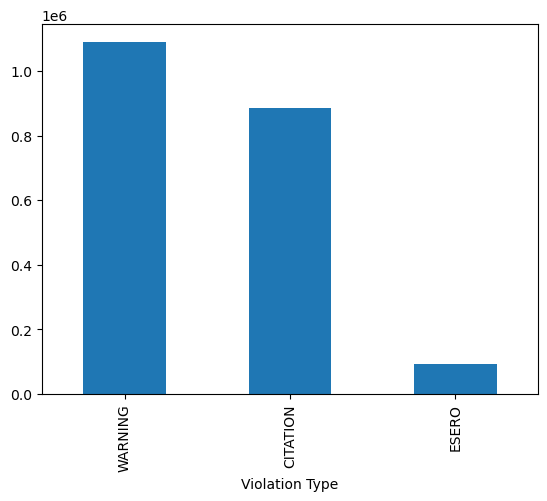

In [85]:
df['Violation Type'].value_counts().plot(kind='bar')

<Axes: ylabel='Charge'>

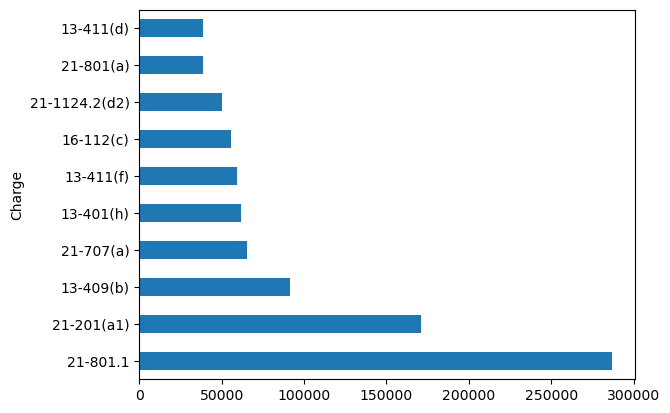

In [86]:
df['Charge'].value_counts().head(10).plot(kind='barh')

<Axes: ylabel='Description'>

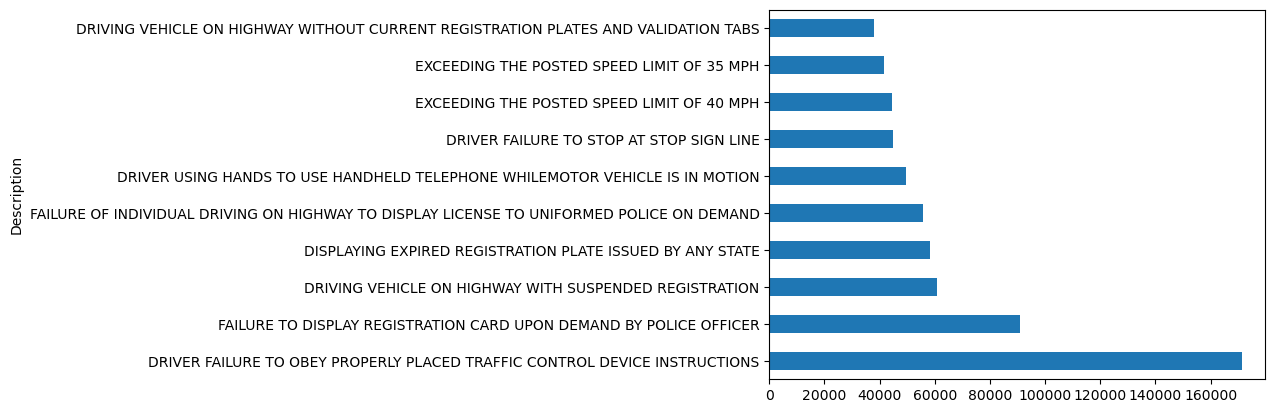

In [87]:
df['Description'].value_counts().head(10).plot(kind='barh')

In [88]:
#Q2 Which areas or coordinates have the highest traffic incidents?

In [89]:
df[['Latitude', 'Longitude']].value_counts().head(20)

Latitude   Longitude 
39.045425  -76.990738    551
39.046276  -76.990692    431
39.109776  -76.910439    327
39.005619  -77.012329    268
39.110611  -76.989799    252
39.057556  -76.967827    210
39.003899  -77.036484    155
39.149277  -77.066620    128
39.077694  -77.046387    128
38.992050  -77.027130    124
39.064575  -76.839989     92
39.057663  -77.048378     85
39.111008  -77.185425     84
39.066055  -77.159439     82
39.058407  -77.048088     80
39.170864  -77.240395     79
39.058426  -77.048035     76
39.099125  -77.042198     75
39.244053  -77.153740     69
39.095192  -76.929100     66
Name: count, dtype: int64

In [90]:
df['Geolocation'].value_counts().head(20)

Geolocation
(0.0, 0.0)                               155744
(39.045425, -76.9907366666667)              551
(39.0462766666667, -76.990695)              431
(39.109775, -76.91044)                      327
(39.0056183333333, -77.0123283333333)       268
(39.11061, -76.9897983333333)               252
(39.057555, -76.9678266666667)              210
(39.0039, -77.036485)                       155
(39.077695, -77.046385)                     128
(39.1492783333333, -77.06662)               128
(38.9920483333333, -77.0271333333333)       124
(39.0645766666667, -76.8399866666667)        92
(39.0576633333333, -77.048375)               85
(39.1110083333333, -77.185425)               84
(39.066055, -77.1594416666667)               82
(39.1708633333333, -77.2403933333333)        79
(39.0991266666667, -77.0421983333333)        75
(39.2440516666667, -77.15374)                69
(38.8702933333333, -94.6109883333333)        66
(39.0951933333333, -76.9291016666667)        66
Name: count, dtype: int64

In [91]:
df['Location'].value_counts().head(20)

Location
MONTGOMERY VILLAGE AVE @ RUSSELL AVE    2449
WAYNE AVE @ DALE DR                     2331
WOODFIELD RD @ EMORY GROVE RD           2202
IS 370 @ IS 270                         1982
RT 28 @ BLACKBERRY DR                   1966
W/B IS 370 @ IS 270                     1882
RIDGE RD @ OBSERVATION DR               1877
GEORGIA AVE @ COLESVILLE RD             1711
COLESVILLE RD @ GEORGIA AVE             1709
CONNECTICUT AVE @ DEAN RD               1688
CONNECTICUT AVE / DEAN RD               1577
10901 WESTLAKE DRIVE                    1509
RANDOLPH / COLIE                        1496
GEORGIA AVE @ HEWITT AVE                1473
WAYNE AVE / DALE DR                     1371
RIVER RD AND ROYAL DOMINION             1357
RIVER RD @ ROYAL DOMINION DR            1344
FREDERICK RD/COLLEGE PKWY               1337
CLOPPER RD E/B @ ORCHARD HILLS DR       1322
GEORGIA AVE/COLESVILLE RD               1227
Name: count, dtype: int64

In [92]:
coord_hotspots = (
    df.groupby([
        df['Latitude'].round(3),
        df['Longitude'].round(3)
    ]).size().sort_values(ascending=False).head(20)
)

coord_hotspots

Latitude   Longitude 
39.057999  -77.047997    14631
39.150002  -77.234001     9355
39.046001  -76.990997     6187
39.058998  -77.047997     6043
39.044998  -76.990997     5699
39.185001  -77.263000     4981
39.061001  -77.053001     4975
39.120998  -77.202003     4785
39.069000  -77.162003     4370
39.183998  -77.263000     4338
39.127998  -77.161003     3900
38.997002  -77.027000     3211
38.984001  -77.093002     3147
38.995998  -77.028000     3022
38.991001  -77.023003     2982
39.106998  -76.940002     2923
38.997002  -77.028000     2850
38.990002  -77.023003     2710
39.116001  -77.248001     2648
39.040001  -77.042999     2455
dtype: int64

<Axes: ylabel='Location'>

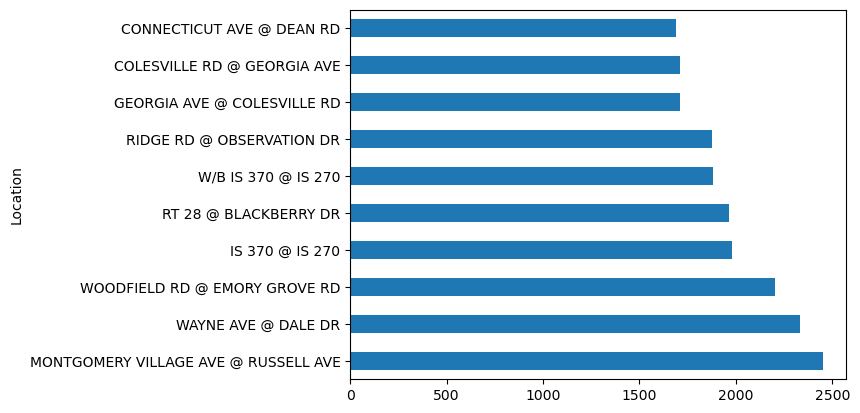

In [93]:
df['Location'].value_counts().head(10).plot(kind='barh')

<Axes: ylabel='Latitude,Longitude'>

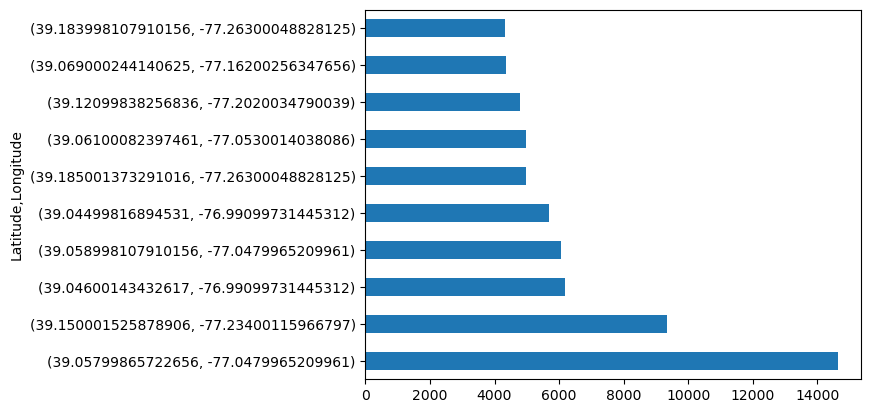

In [94]:
coord_hotspots.head(10).plot(kind='barh')

In [95]:
#Q3 Do certain demographics correlate with specific violation types?

In [96]:
df['Violation Type'].value_counts()

Violation Type
WARNING     1089807
CITATION     885280
ESERO         92674
Name: count, dtype: int64

In [97]:
pd.crosstab(df['Race'], df['Violation Type'])

Violation Type,CITATION,ESERO,WARNING
Race,,,
ASIAN,40918,5510,70224
BLACK,287221,28065,340139
HISPANIC,232536,26303,205082
NATIVE AMERICAN,1409,232,1875
OTHER,47509,5890,84430
WHITE,275687,26674,388057


In [98]:
pd.crosstab(df['Gender'], df['Violation Type'])

Violation Type,CITATION,ESERO,WARNING
Gender,,,
F,250848,28233,392928
M,633999,64424,693808
U,433,17,3071


In [99]:
top_charges = df['Charge'].value_counts().head(10).index

pd.crosstab(
    df[df['Charge'].isin(top_charges)]['Race'],
    df[df['Charge'].isin(top_charges)]['Charge']
)[top_charges]


Charge,21-801.1,21-201(a1),13-409(b),21-707(a),13-401(h),13-411(f),16-112(c),21-1124.2(d2),21-801(a),13-411(d)
Race,,,,,,,,,,
ASIAN,19425,11201,6350,6079,2121,3207,2073,3043,2400,2017
BLACK,69691,48926,31018,14582,25864,21190,19078,12301,11134,13240
HISPANIC,44707,33151,18354,11353,11534,8412,17528,9033,7610,5844
NATIVE AMERICAN,357,351,153,146,85,95,77,120,77,61
OTHER,27959,11874,5872,4688,3066,4003,2912,4129,2814,2312
WHITE,124558,65771,29681,28680,18823,22696,13883,21311,14402,14950


<Axes: ylabel='Race'>

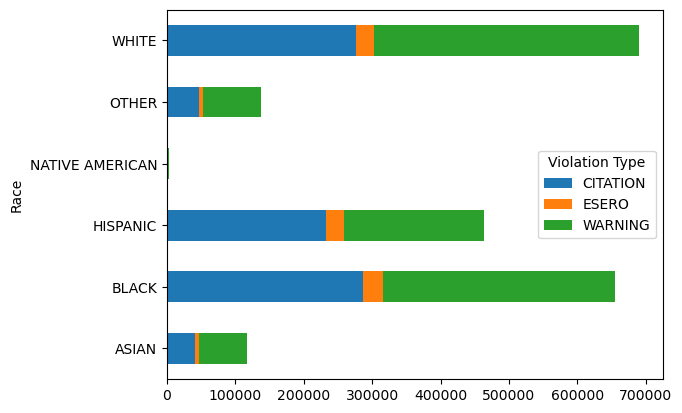

In [100]:
pd.crosstab(df['Race'], df['Violation Type']).plot(kind='barh', stacked=True)

<Axes: xlabel='Race'>

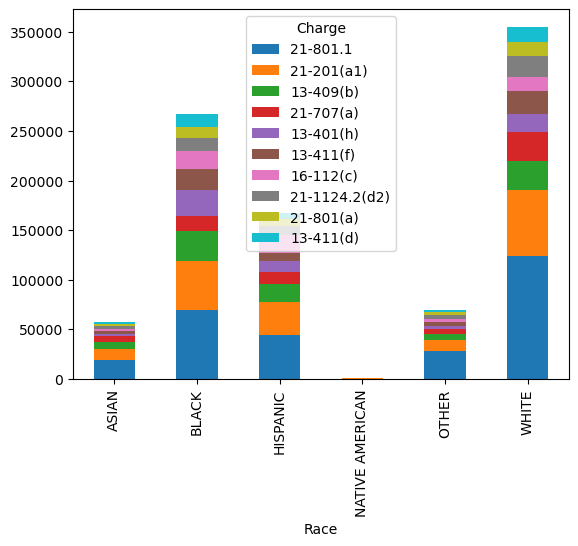

In [101]:
pd.crosstab(
    df[df['Charge'].isin(top_charges)]['Race'],
    df[df['Charge'].isin(top_charges)]['Charge']
)[top_charges].plot(kind='bar', stacked=True)

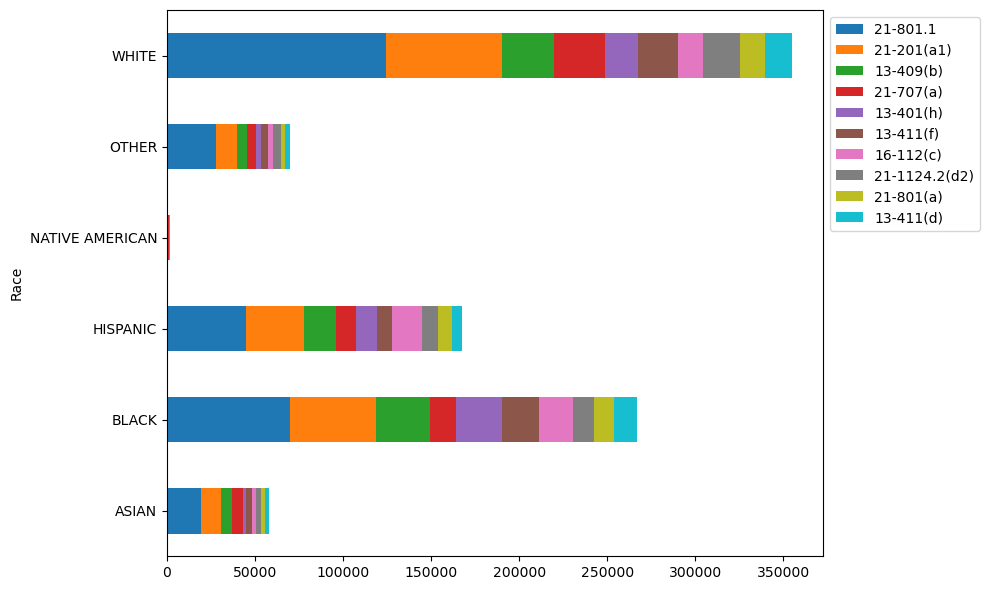

In [102]:
pd.crosstab(
    df[df['Charge'].isin(top_charges)]['Race'],
    df[df['Charge'].isin(top_charges)]['Charge']
)[top_charges].plot(
    kind='barh',
    stacked=True,
    figsize=(10,6)
)

plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()

In [103]:
#Q4 How does violation frequency vary by time of day, weekday, or month?

In [104]:
df['time_bucket'].value_counts()

time_bucket
Night        759165
Morning      546608
Afternoon    424703
Evening      337285
Name: count, dtype: int64

In [105]:
df['stop_datetime'].value_counts().head(20)

stop_datetime
2017-04-27 14:36:00    59
2021-12-11 04:32:00    46
2020-01-06 23:55:00    43
2014-03-25 06:57:00    42
2015-02-01 00:50:00    40
2015-07-02 05:46:00    39
2016-04-11 22:42:00    39
2016-10-24 21:17:00    38
2017-09-20 22:08:00    36
2019-10-25 04:12:00    35
2016-03-15 21:10:00    34
2013-04-10 10:09:00    34
2016-06-06 00:38:00    33
2018-08-19 20:30:00    33
2015-01-07 04:21:00    33
2023-09-23 03:28:00    32
2017-04-30 21:21:00    32
2018-11-11 03:45:00    32
2013-09-01 02:55:00    31
2013-04-10 01:47:00    31
Name: count, dtype: int64

In [106]:
df['weekday'].value_counts()

weekday
Tuesday      365332
Wednesday    339495
Thursday     324258
Friday       320861
Monday       281155
Saturday     230883
Sunday       205777
Name: count, dtype: int64

In [107]:
weekday_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

df['weekday'].value_counts().reindex(weekday_order)

weekday
Monday       281155
Tuesday      365332
Wednesday    339495
Thursday     324258
Friday       320861
Saturday     230883
Sunday       205777
Name: count, dtype: int64

In [108]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

df['month'].value_counts().reindex(month_order)

month
January      166400
February     175876
March        194062
April        178025
May          181654
June         160607
July         166841
August       167350
September    170084
October      172689
November     173576
December     160597
Name: count, dtype: int64

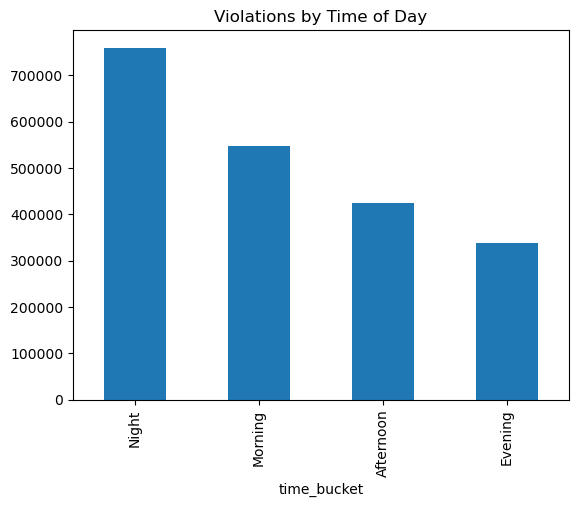

In [109]:
df['time_bucket'].value_counts().plot(kind='bar')
plt.title('Violations by Time of Day')
plt.show()

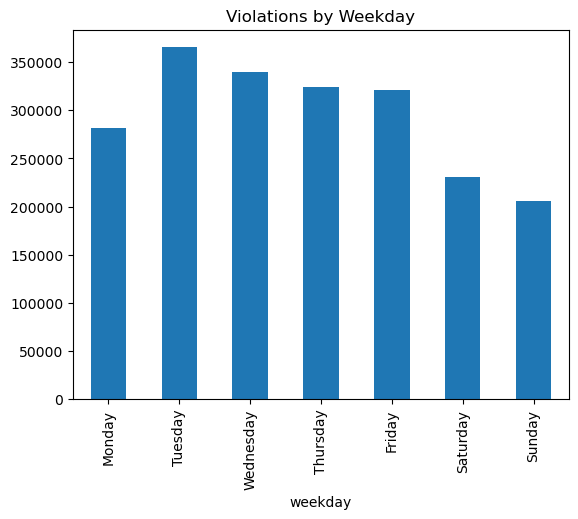

In [110]:
weekday_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

df['weekday'].value_counts().reindex(weekday_order).plot(kind='bar')
plt.title('Violations by Weekday')
plt.show()

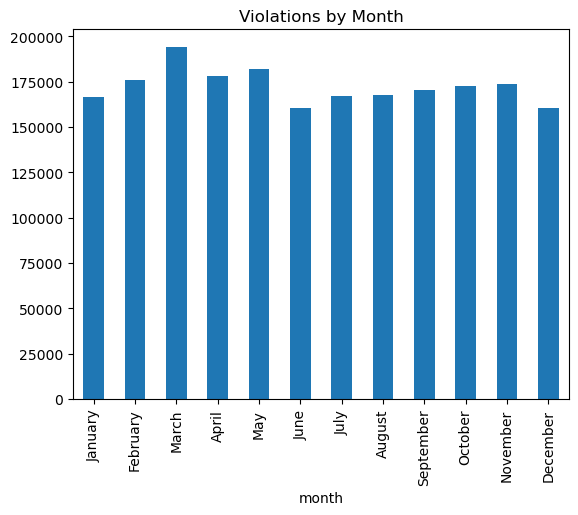

In [111]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

df['month'].value_counts().reindex(month_order).plot(kind='bar')
plt.title('Violations by Month')
plt.show()

In [112]:
# Q5 What types of vehicles are most often involved in violations?

In [113]:
df['VehicleType'].value_counts().head(20)

VehicleType
02 - AUTOMOBILE              1833630
05 - LIGHT DUTY TRUCK         108173
28 - OTHER                     35171
03 - STATION WAGON             28614
01 - MOTORCYCLE                19052
06 - HEAVY DUTY TRUCK          16426
29 - UNKNOWN                   11183
08 - RECREATIONAL VEHICLE       5502
19 - MOPED                      2308
25 - UTILITY TRAILER            1965
07 - TRUCK/ROAD TRACTOR         1816
20 - COMMERCIAL RIG             1144
04 - LIMOUSINE                   959
10 - TRANSIT BUS                 685
12 - SCHOOL BUS                  432
27 - FARM EQUIPMENT              135
09 - FARM VEHICLE                108
26 - BOAT TRAILER                101
21 - TANDEM TRAILER               88
11 - CROSS COUNTRY BUS            66
Name: count, dtype: int64

In [114]:
print("Unique vehicle types:", df['VehicleType'].nunique())
print("Missing vehicle types:", df['VehicleType'].isna().sum())

Unique vehicle types: 30
Missing vehicle types: 0


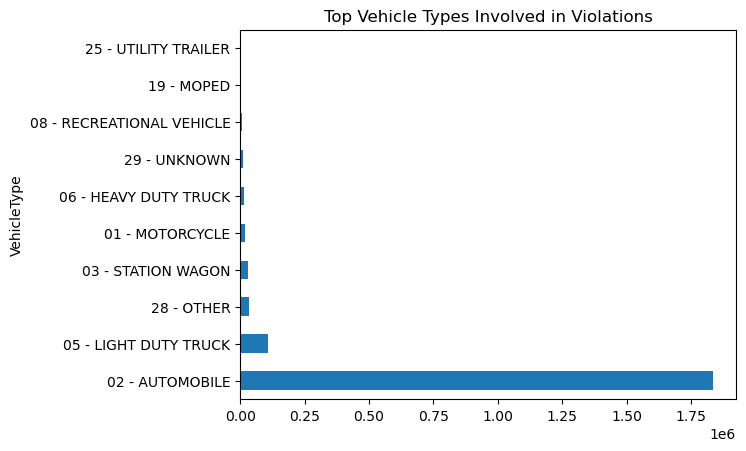

In [115]:
df['VehicleType'].value_counts().head(10).plot(kind='barh')
plt.title('Top Vehicle Types Involved in Violations')
plt.show()

In [116]:
#Q6 How often do violations involve accidents, injuries, or vehicle damage?

In [117]:
df['Accident'].value_counts()

Accident
False    2011283
True       56478
Name: count, dtype: int64

In [118]:
df['Personal Injury'].value_counts()

Personal Injury
False    2042652
True       25109
Name: count, dtype: int64

In [119]:
df['Property Damage'].value_counts()

Property Damage
False    2022620
True       45141
Name: count, dtype: int64

In [120]:
df['Fatal'].value_counts()

Fatal
False    2067194
True         567
Name: count, dtype: int64

In [121]:
df['Contributed To Accident'].value_counts()

Contributed To Accident
False    2011283
True       56478
Name: count, dtype: int64

In [122]:
cols = [
    'Accident',
    'Personal Injury',
    'Property Damage',
    'Fatal',
    'Contributed To Accident'
]

(df[cols].mean()*100).round(2)

Accident                   2.73
Personal Injury            1.21
Property Damage            2.18
Fatal                      0.03
Contributed To Accident    2.73
dtype: float64

In [123]:
(df['Accident'] == df['Contributed To Accident']).all()

np.True_

In [124]:
df = df.drop(columns=['Contributed To Accident'])

In [125]:
df.to_csv('data/cleaned/cleaned_traffic_stops.csv', index=False)

In [126]:
df.shape

(2067761, 46)

In [127]:
df['stop_datetime'].head(20)

0    2023-05-01 23:11:00
1    2023-08-31 16:41:00
2    2023-08-31 16:41:00
3    2023-08-31 16:41:00
4    2023-08-31 16:41:00
5    2023-04-30 23:55:00
6    2023-08-31 16:41:00
7    2023-08-31 16:41:00
8    2023-08-31 16:41:00
9    2023-08-31 16:41:00
10   2023-08-31 16:41:00
11   2023-08-31 16:41:00
12   2023-08-31 08:59:00
13   2023-09-01 00:27:00
14   2023-08-31 08:59:00
15   2023-04-30 04:24:00
16   2023-04-30 04:24:00
17   2023-04-30 04:24:00
18   2023-04-30 04:24:00
19   2023-04-30 04:24:00
Name: stop_datetime, dtype: datetime64[ns]

In [128]:
print(df["stop_datetime"].dtype)

datetime64[ns]


In [129]:
df['date'].head(20)

0     01/05/2023
1     31/08/2023
2     31/08/2023
3     31/08/2023
4     31/08/2023
5     30/04/2023
6     31/08/2023
7     31/08/2023
8     31/08/2023
9     31/08/2023
10    31/08/2023
11    31/08/2023
12    31/08/2023
13    01/09/2023
14    31/08/2023
15    30/04/2023
16    30/04/2023
17    30/04/2023
18    30/04/2023
19    30/04/2023
Name: date, dtype: object

In [130]:
for col in df.columns:
    print(col, "->", df[col].nunique())

SeqID -> 1178080
Date Of Stop -> 5086
Time Of Stop -> 1440
Agency -> 1
SubAgency -> 9
Description -> 17807
Location -> 269353
Latitude -> 81993
Longitude -> 55809
Accident -> 2
Belts -> 2
Personal Injury -> 2
Property Damage -> 2
Fatal -> 2
Commercial License -> 2
HAZMAT -> 2
Commercial Vehicle -> 2
Alcohol -> 2
Work Zone -> 2
Search Conducted -> 3
Search Outcome -> 6
State -> 73
VehicleType -> 30
Year -> 86
Make -> 4935
Model -> 23386
Color -> 27
Violation Type -> 3
Charge -> 1199
Article -> 7
Race -> 6
Gender -> 3
Driver City -> 9374
Driver State -> 69
DL State -> 73
Arrest Type -> 19
Geolocation -> 1026161
stop_datetime -> 1021271
date -> 5086
time -> 1440
hour -> 24
weekday -> 7
month -> 12
time_bucket -> 4
violation_count -> 438
accident_severity -> 5


In [131]:
df['Description'].value_counts().head(15)

Description
DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC CONTROL DEVICE INSTRUCTIONS                              171274
FAILURE TO DISPLAY REGISTRATION CARD UPON DEMAND BY POLICE OFFICER                                       91000
DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGISTRATION                                                   60761
DISPLAYING EXPIRED REGISTRATION PLATE ISSUED BY ANY STATE                                                58402
FAILURE OF INDIVIDUAL DRIVING ON HIGHWAY TO DISPLAY LICENSE TO UNIFORMED POLICE ON DEMAND                55565
DRIVER USING HANDS TO USE HANDHELD TELEPHONE WHILEMOTOR VEHICLE IS IN MOTION                             49500
DRIVER FAILURE TO STOP AT STOP SIGN LINE                                                                 45003
EXCEEDING THE POSTED SPEED LIMIT OF 40 MPH                                                               44621
EXCEEDING THE POSTED SPEED LIMIT OF 35 MPH                                                          

In [132]:
df.shape

(2067761, 46)

In [133]:
cols = [
    'Accident',
    'Personal Injury',
    'Property Damage',
    'Fatal',
]

(df[cols].sum())

Accident           56478
Personal Injury    25109
Property Damage    45141
Fatal                567
dtype: int64

In [134]:
df['time_bucket'].value_counts()

time_bucket
Night        759165
Morning      546608
Afternoon    424703
Evening      337285
Name: count, dtype: int64

In [135]:
df.columns

Index(['SeqID', 'Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency',
       'Description', 'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License',
       'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone',
       'Search Conducted', 'Search Outcome', 'State', 'VehicleType', 'Year',
       'Make', 'Model', 'Color', 'Violation Type', 'Charge', 'Article', 'Race',
       'Gender', 'Driver City', 'Driver State', 'DL State', 'Arrest Type',
       'Geolocation', 'stop_datetime', 'date', 'time', 'hour', 'weekday',
       'month', 'time_bucket', 'violation_count', 'accident_severity'],
      dtype='object')

In [136]:
df['Year'].value_counts()

Year
2008.0    115967
2007.0    111399
2013.0    110226
2006.0    110102
2012.0    108133
           ...  
1955.0         1
1902.0         1
1951.0         1
1936.0         1
1959.0         1
Name: count, Length: 86, dtype: int64

In [138]:
df['Violation Type'].value_counts()

Violation Type
WARNING     1089807
CITATION     885280
ESERO         92674
Name: count, dtype: int64

In [139]:
df['Charge'].value_counts()

Charge
21-801.1          286697
21-201(a1)        171274
13-409(b)          91428
21-707(a)          65528
13-401(h)          61493
                   ...  
11-383.3B              1
11-172.33(4b)          1
11-172.32(8b1)         1
21-1209(b)             1
21-1208(e)             1
Name: count, Length: 1199, dtype: int64

POST CLEANING

In [141]:
df.columns

Index(['SeqID', 'Date Of Stop', 'Time Of Stop', 'Agency', 'SubAgency',
       'Description', 'Location', 'Latitude', 'Longitude', 'Accident', 'Belts',
       'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License',
       'HAZMAT', 'Commercial Vehicle', 'Alcohol', 'Work Zone',
       'Search Conducted', 'Search Outcome', 'State', 'VehicleType', 'Year',
       'Make', 'Model', 'Color', 'Violation Type', 'Charge', 'Article', 'Race',
       'Gender', 'Driver City', 'Driver State', 'DL State', 'Arrest Type',
       'Geolocation', 'stop_datetime', 'date', 'time', 'hour', 'weekday',
       'month', 'time_bucket', 'violation_count', 'accident_severity'],
      dtype='object')

In [142]:
vehicle_cols = [
    "VehicleType",
    "Year",
    "Make",
    "Model",
    "Color",
    "Commercial Vehicle",
    "Commercial License",
    "HAZMAT"
]

for col in vehicle_cols:
    print("\n" + "="*50)
    print(col)
    print("="*50)
    print(df[col].value_counts(dropna=False).head(20))


VehicleType
VehicleType
02 - AUTOMOBILE              1833630
05 - LIGHT DUTY TRUCK         108173
28 - OTHER                     35171
03 - STATION WAGON             28614
01 - MOTORCYCLE                19052
06 - HEAVY DUTY TRUCK          16426
29 - UNKNOWN                   11183
08 - RECREATIONAL VEHICLE       5502
19 - MOPED                      2308
25 - UTILITY TRAILER            1965
07 - TRUCK/ROAD TRACTOR         1816
20 - COMMERCIAL RIG             1144
04 - LIMOUSINE                   959
10 - TRANSIT BUS                 685
12 - SCHOOL BUS                  432
27 - FARM EQUIPMENT              135
09 - FARM VEHICLE                108
26 - BOAT TRAILER                101
21 - TANDEM TRAILER               88
11 - CROSS COUNTRY BUS            66
Name: count, dtype: int64

Year
Year
2008.0    115967
2007.0    111399
2013.0    110226
2006.0    110102
2012.0    108133
2005.0    105819
2004.0    101925
2011.0     98887
2014.0     97605
2015.0     96350
2003.0     94698
2010.0     

In [144]:
cols = [
    "SeqID",
    "Date Of Stop",
    "Time Of Stop",
    "Agency",
    "SubAgency"
]

for col in cols:
    print(col)
    print("="*50)
    print("Data type:", df[col].dtype)
    print("Missing values:", df[col].isna().sum())
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))

SeqID
Data type: object
Missing values: 0
Unique values: 1178080
SeqID
33c49de3-9e36-4f36-9326-b59a95e86fe8    59
6c64b741-3b7e-4658-9fed-fd5c3af27250    43
28c5bfc1-5670-4751-be16-e1d83cda20f0    42
c474e98e-128c-40e0-a487-d988cc67f0bd    39
859768f4-bde0-427b-a60f-07b1e2aaadc4    39
42ee969e-cc65-4557-bc1a-cefa6b35cba8    38
8fe624e5-2bef-4cf9-963b-58fbb1e206c2    37
09829461-7b79-4eb8-87f8-0c2bc3d1fe27    35
d8c32585-3c35-4862-987b-aa65d36a53db    35
1f0803c8-b026-4f42-a04b-a3c43404e26f    34
Name: count, dtype: int64
Date Of Stop
Data type: object
Missing values: 0
Unique values: 5086
Date Of Stop
03/17/2015    1278
04/10/2018    1277
05/20/2014    1222
04/18/2018    1185
03/05/2019    1185
11/24/2015    1169
01/25/2017    1166
12/08/2015    1149
03/08/2016    1139
02/11/2015    1135
Name: count, dtype: int64
Time Of Stop
Data type: object
Missing values: 0
Unique values: 1440
Time Of Stop
23:30:00    2992
22:50:00    2911
22:42:00    2885
22:55:00    2874
23:00:00    2867
22:39:00

In [ ]:
# SUB AGENCY

In [145]:
df["SubAgency"] = df["SubAgency"].astype(str).str.strip()

df["SubAgency"] = df["SubAgency"].replace({
    "W15": "OTHER",
    "S15": "OTHER"
})

df["SubAgency"] = df["SubAgency"].astype("category")

In [146]:
df["SubAgency"].value_counts(dropna=False)

SubAgency
4th District, Wheaton                              448580
3rd District, Silver Spring                        373052
2nd District, Bethesda                             325179
6th District, Gaithersburg / Montgomery Village    261210
5th District, Germantown                           245529
1st District, Rockville                            240652
Headquarters and Special Operations                173549
OTHER                                                  10
Name: count, dtype: int64

In [ ]:
# LOCATION

In [147]:
df["Location"] = df["Location"].astype(str).str.strip().str.upper()

bad_locations = ["-", "N", "NA", "N/A", "NONE", "NULL", ".", "?"]

df["Location"] = df["Location"].replace(bad_locations, "UNKNOWN")

In [ ]:
# LATITUDE AND LONGITUDE

In [148]:
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")

df.loc[df["Latitude"] == 0, "Latitude"] = np.nan
df.loc[df["Longitude"] == 0, "Longitude"] = np.nan

invalid_coord_mask = (
    (df["Latitude"] < 24) |
    (df["Latitude"] > 50) |
    (df["Longitude"] < -125) |
    (df["Longitude"] > -65)
)

df.loc[invalid_coord_mask, ["Latitude", "Longitude"]] = np.nan

In [151]:
cols_to_check = [
    "Description",
    "Location",
    "Latitude",
    "Longitude",
    "Accident",
    "Belts",
    "Personal Injury",
    "Property Damage",
    "Fatal",
    "Commercial License",
    "HAZMAT",
    "Commercial Vehicle",
    "Alcohol"
]

for col in cols_to_check:
    print("\n" + "="*50)
    print(col)
    print("="*50)
    print("Data type:", df[col].dtype)
    print("Missing values:", df[col].isna().sum())
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


Description
Data type: object
Missing values: 0
Unique values: 17807
Description
DRIVER FAILURE TO OBEY PROPERLY PLACED TRAFFIC CONTROL DEVICE INSTRUCTIONS                   171274
FAILURE TO DISPLAY REGISTRATION CARD UPON DEMAND BY POLICE OFFICER                            91000
DRIVING VEHICLE ON HIGHWAY WITH SUSPENDED REGISTRATION                                        60761
DISPLAYING EXPIRED REGISTRATION PLATE ISSUED BY ANY STATE                                     58402
FAILURE OF INDIVIDUAL DRIVING ON HIGHWAY TO DISPLAY LICENSE TO UNIFORMED POLICE ON DEMAND     55565
DRIVER USING HANDS TO USE HANDHELD TELEPHONE WHILEMOTOR VEHICLE IS IN MOTION                  49500
DRIVER FAILURE TO STOP AT STOP SIGN LINE                                                      45003
EXCEEDING THE POSTED SPEED LIMIT OF 40 MPH                                                    44621
EXCEEDING THE POSTED SPEED LIMIT OF 35 MPH                                                    41581
DRIVING VEHICLE ON

In [ ]:
# MAKE

In [155]:
cols_to_check = [
    "Search Arrest Reason",
    "State",
    "VehicleType",
    "Year",
    "Make"
]

for col in cols_to_check:
    print("\n" + "="*50)
    print(col)
    print("="*50)

    if col in df.columns:
        print("Data type:", df[col].dtype)
        print("Missing values:", df[col].isna().sum())
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts(dropna=False).head(20))
    else:
        print("Column not present in dataframe. Probably dropped earlier.")


Search Arrest Reason
Column not present in dataframe. Probably dropped earlier.

State
Data type: category
Missing values: 0
Unique values: 73
State
MD    1795997
VA      98165
DC      50874
XX      16419
PA      14284
TX      10106
FL      10023
WV       8282
NC       7518
NY       6521
NJ       5871
GA       4447
DE       3832
CA       3511
OH       3195
MA       2690
IL       2182
SC       2123
TN       1939
MI       1638
Name: count, dtype: int64

VehicleType
Data type: category
Missing values: 0
Unique values: 30
VehicleType
02 - AUTOMOBILE              1833630
05 - LIGHT DUTY TRUCK         108173
28 - OTHER                     35171
03 - STATION WAGON             28614
01 - MOTORCYCLE                19052
06 - HEAVY DUTY TRUCK          16426
29 - UNKNOWN                   11183
08 - RECREATIONAL VEHICLE       5502
19 - MOPED                      2308
25 - UTILITY TRAILER            1965
07 - TRUCK/ROAD TRACTOR         1816
20 - COMMERCIAL RIG             1144
04 - LIMOUSINE     

In [156]:
df["Make"] = df["Make"].astype(str).str.strip().str.upper()

make_mapping = {
    "TOYT": "TOYOTA",
    "HOND": "HONDA",
    "NISS": "NISSAN",
    "CHEV": "CHEVROLET",
    "CHEVY": "CHEVROLET",
    "HYUN": "HYUNDAI",
    "MERZ": "MERCEDES"
}

df["Make"] = df["Make"].replace(make_mapping)

df["Make"] = df["Make"].astype("category")

In [157]:
df["Make"].value_counts().head(20)

Make
TOYOTA       356952
HONDA        307303
FORD         187504
NISSAN       153577
CHEVROLET    148273
HYUNDAI       72743
BMW           59101
DODGE         52447
MERCEDES      49481
JEEP          48693
ACURA         45334
LEXUS         34153
KIA           32450
MAZDA         29521
GMC           26684
AUDI          21785
SUBARU        20713
VOLK          18306
ACUR          17102
CHRYSLER      15372
Name: count, dtype: int64

In [ ]:
#GEOLOCATION

In [162]:
df.drop(columns=["Geolocation"], inplace=True)

In [164]:
df.to_csv("data/cleaned/cleaned_traffic_stops.csv", index=False)